# Predictive Maintenance — Turbofan Engine Health Classification

**Dataset**: NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)  
**Source**: [Kaggle — behrad3d/nasa-cmaps](https://www.kaggle.com/datasets/behrad3d/nasa-cmaps)  
**Task**: Multi-class health classification — *Healthy / Degrading / Critical*  
**Models**: FLAML AutoML (tabular rolling features) · LSTM (sensor time-series sequences)  
**Processing**: Pandas-based feature engineering with operating-condition normalisation  

---

The C-MAPSS dataset simulates turbofan engine degradation under varying operating conditions.
Four sub-datasets (FD001–FD004) differ in the number of operating regimes (1 or 6) and
fault modes (1 or 2).  Each row is one engine cycle with readings from 21 sensors.
The objective is to classify the current health state of an engine from its sensor history,
enabling early intervention before catastrophic failure.

**Health-state encoding**  
RUL (Remaining Useful Life) is derived from training run-to-failure data:
- `Healthy (0)` : capped RUL > 80 cycles  
- `Degrading (1)` : 30 < capped RUL ≤ 80 cycles  
- `Critical (2)` : capped RUL ≤ 30 cycles  

In [1]:
# =========================================================
# 0. Imports & Configuration
# =========================================================

# --- Standard library ---
import importlib.util
import itertools
import sys
import warnings
from pathlib import Path

# --- Third-party core ---
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Scikit-learn ---
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# --- AutoML & experiment tracking ---
import mlflow
import mlflow.sklearn

# --- SHAP ---
import shap

# --- Project utils ---
def _load_module(name: str, rel_path: str):
    """Dynamically load a utility module by relative file path."""
    spec = importlib.util.spec_from_file_location(name, Path(rel_path))
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    sys.modules[name] = mod
    return mod

plot_style = _load_module("plot_style", "utils/plot_style.py")
from plot_style import (  # noqa: E402
    apply_style, FigSize,
    CMAP, C1, C2, C3,
    CMAP_DMG, D1, D2, D3,
    CMAP_IR,  I1, I2, I3,
    blues, salmons, greens,
)

from utils.download_dataset import get_data_dir
from utils.data_loader import (
    load_all_fds, compute_rul, attach_test_rul,
    USEFUL_SENSORS, OP_SETTINGS, CLASS_NAMES,
)
from utils.feature_engineering import (
    add_rolling_features_spark,
    add_long_window_features,
    min_max_normalise_spark, apply_min_max_spark,
    fit_condition_normaliser, apply_condition_normaliser,
    create_lstm_sequences, get_feature_cols,
)
from utils.ml_classification import (
    run_automl_with_mlflow,
    tune_prediction_threshold, group_cv_score,
    build_lstm_model, train_lstm,
    evaluate_classification, get_confusion_matrix,
    save_model, load_model,
)

warnings.filterwarnings("ignore")
apply_style()

c:\Users\20215518\Anaconda3\envs\ds-py311\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


In [2]:
# --- Global constants (Section 0 — change here and re-run) ---

RANDOM_STATE = 42       # global seed — never change between notebooks
TEST_SIZE    = 0.20     # held-out test fraction
N_SPLITS     = 5        # cross-validation folds

# Dataset configuration
FD_IDS          = [1, 2, 3, 4]
DATA_DIR        = "data/raw"

# Feature engineering
WINDOW_SIZE      = 30
LONG_WINDOW_SIZE = 100
LSTM_SEQ_LEN     = 100
N_OP_CLUSTERS    = 6

# Health-class thresholds (defaults — may be overridden by threshold search in Section 3)
RUL_CAP_VAL      = 125
RUL_HEALTHY_VAL  = 80   # RUL > 80  → Healthy
RUL_CRITICAL_VAL = 30   # RUL ≤ 30  → Critical

# Threshold search — set True to find data-driven Healthy/Critical boundaries
# via a fast ExtraTrees proxy before the main FLAML search.
# Adds ~2–4 min but can improve Degrading recall if default thresholds are suboptimal.
ENABLE_THRESHOLD_SEARCH = True
THRESHOLD_SEARCH_FOLDS  = 3      # folds for proxy CV (fewer = faster)
THRESHOLD_SEARCH_SAMPLE = 0.4    # fraction of training rows used (speeds up search)

# AutoML (FLAML)
AUTOML_TIME_BUDGET  = 600
AUTOML_METRIC       = "f1_weighted"
MLFLOW_EXPERIMENT   = "turbofan-health-classification"
MLFLOW_TRACKING_URI = "./mlruns"

# LSTM
ENABLE_LSTM     = False
LSTM_UNITS      = [128, 64]
LSTM_DROPOUT    = 0.2
LSTM_EPOCHS     = 50
LSTM_BATCH      = 256
LSTM_PATIENCE   = 10

# SHAP
SHAP_SAMPLE_SIZE = 500
SHAP_CLASS       = 2

# Output paths
MODEL_DIR  = Path("models");  MODEL_DIR.mkdir(exist_ok=True)
ASSETS_DIR = Path("assets");  ASSETS_DIR.mkdir(exist_ok=True)

CLASS_COLORS  = {"Healthy": C1, "Degrading": D1, "Critical": I1}
CLASS_PALETTE = [C1, D1, I1]

## 1. Data Acquisition

The NASA C-MAPSS dataset is downloaded via `kagglehub` (cached after the first run).
If data is already present in `data/raw/`, the download is skipped.
All four sub-datasets (FD001–FD004) are loaded and concatenated into a single
pandas DataFrame.

In [3]:
# =========================================================
# 1. Data Acquisition
# =========================================================

# --- 1a. Download / locate dataset ---
data_dir = get_data_dir(DATA_DIR)
print(f"\nData directory : {data_dir}")

Local data found at: data\raw

Data directory : data\raw


In [4]:
# --- 1b. Load raw training data ---
df_raw = load_all_fds(data_dir, fds=FD_IDS, split="train")

print(f"Raw training rows : {len(df_raw):,}")
print(f"Columns           : {df_raw.shape[1]}")
display(df_raw.iloc[200:210])

# Build df_eda so Section 2 has labelled data available
# compute_rul is called again in Section 3 as the canonical df_labelled
df_eda = compute_rul(df_raw)
df_eda["health_label"] = df_eda["health_class"].map(dict(enumerate(CLASS_NAMES)))

Raw training rows : 160,359
Columns           : 27


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,fd_id
200,1002,9,0.0017,-0.0004,100.0,518.67,641.98,1581.99,1395.01,14.62,...,2387.98,8145.29,8.3868,0.03,390,2388,100.0,39.06,23.4875,1
201,1002,10,-0.0045,0.0002,100.0,518.67,641.99,1586.37,1394.86,14.62,...,2387.97,8138.64,8.3982,0.03,391,2388,100.0,39.20,23.6005,1
202,1002,11,0.0006,0.0004,100.0,518.67,642.26,1589.21,1401.29,14.62,...,2388.03,8135.85,8.4188,0.03,392,2388,100.0,39.23,23.3888,1
203,1002,12,0.0002,0.0006,100.0,518.67,641.64,1579.99,1401.90,14.62,...,2387.97,8136.49,8.3925,0.03,392,2388,100.0,39.12,23.4201,1
204,1002,13,0.0007,0.0005,100.0,518.67,641.78,1586.77,1401.53,14.62,...,2387.99,8140.61,8.3742,0.03,391,2388,100.0,38.88,23.4317,1
205,1002,14,-0.0024,-0.0004,100.0,518.67,641.66,1584.04,1395.46,14.62,...,2387.98,8140.09,8.3887,0.03,391,2388,100.0,38.93,23.4074,1
206,1002,15,-0.0012,-0.0003,100.0,518.67,642.21,1579.84,1402.11,14.62,...,2388.02,8137.72,8.3704,0.03,393,2388,100.0,38.94,23.4311,1
207,1002,16,-0.0010,0.0003,100.0,518.67,641.81,1581.99,1393.46,14.62,...,2387.95,8133.45,8.3805,0.03,392,2388,100.0,39.01,23.4462,1
208,1002,17,0.0003,-0.0001,100.0,518.67,642.43,1583.58,1390.27,14.62,...,2388.08,8134.78,8.3714,0.03,391,2388,100.0,39.04,23.5245,1
209,1002,18,0.0014,0.0001,100.0,518.67,641.95,1588.43,1400.25,14.62,...,2388.00,8133.20,8.4053,0.03,391,2388,100.0,39.00,23.4203,1


In [5]:
# --- 1c. Load raw test data (official held-out split) ---
# The C-MAPSS dataset ships with a predefined engine-level train/test partition:
#   train_FD00X.txt  — complete run-to-failure trajectories (labels derived from last cycle)
#   test_FD00X.txt   — truncated trajectories of unseen engines (never failed in the file)
#   RUL_FD00X.txt    — ground-truth RUL at the last observed cycle for each test engine
#
# We load the test files here and attach labels in Section 3 after RUL computation.
df_raw_test = load_all_fds(data_dir, fds=FD_IDS, split="test")
print(f"Raw test rows    : {len(df_raw_test):,}")
print(f"Test engines     : {df_raw_test['unit_nr'].nunique()}")
display(df_raw_test.groupby("fd_id")["unit_nr"].nunique().rename("test_engines").to_frame())

Raw test rows    : 104,897
Test engines     : 707


,test_engines
fd_id,
1,100
2,259
3,100
4,248


### Data Structure

Each row represents **one engine cycle** (one timestep for one engine unit).
The raw file has no header — columns are assigned by position:

| Group | Columns | Count | Description |
|---|---|---|---|
| **Identity** | `unit_nr`, `time_cycles` | 2 | Engine ID (globally unique) · cycle index (1 → failure) |
| **Operational settings** | `op_setting_1/2/3` | 3 | Throttle resolver angle, altitude, Mach number |
| **Sensors** | `sensor_01` – `sensor_21` | 21 | Thermodynamic measurements (temps, pressures, speeds, ratios) |
| **Provenance** | `fd_id` | 1 | Sub-dataset index (1–4) — added on load |

**Key sensors used** (7 near-constant sensors dropped based on literature):

| Sensor | Physical meaning |
|---|---|
| s02 | LPC outlet temperature (°R) |
| s03 | HPC outlet temperature (°R) |
| s04 | LPT outlet temperature (°R) |
| s07 | HPC outlet static pressure (psia) |
| s08 | Fuel flow ratio (pps/psia) |
| s09 | Bypass ratio |
| s11 | HPC outlet static pressure (psia) |
| s12 | Ratio of fuel flow to Ps30 |
| s13 | Corrected core speed (rpm) |
| s14 | Corrected fan speed (rpm) |
| s15 | HPT coolant bleed (lbm/s) |
| s17 | Demanded fan speed (rpm) |
| s20 | Demanded corrected fan speed (rpm) |
| s21 | HPT coolant bleed (lbm/s) |

**Sub-dataset characteristics:**

| FD | Operating conditions | Fault modes | Train engines |
|---|---|---|---|
| FD001 | 1 | 1 (HPC degradation) | 100 |
| FD002 | 6 | 1 (HPC degradation) | 260 |
| FD003 | 1 | 2 (HPC + fan degradation) | 100 |
| FD004 | 6 | 2 (HPC + fan degradation) | 249 |

,Group,Count,Columns,dtype,example (row 0)
0,Identity,2,"unit_nr, time_cycles",int64,"[1001, 1]"
1,Operational settings,3,"op_setting_1, op_setting_2, op_setting_3",float64,"[-0.0007, -0.0004, 100.0]"
2,Sensors (dropped),7,"sensor_01, sensor_05, sensor_06, sensor_10, se...",float64,"[518.67, 14.62, 21.61, 1.3, 0.03, 2388.0, 100.0]"
3,Sensors (used),14,"sensor_02, sensor_03, sensor_04, sensor_07, se...",float64,"[641.82, 1589.7, 1400.6, 554.36, 2388.06, 9046..."
4,Provenance,1,fd_id,int64,[1]



Engines (train)     : 709
Life per engine     : min=128, median=207, max=543 cycles
Total rows          : 160,359


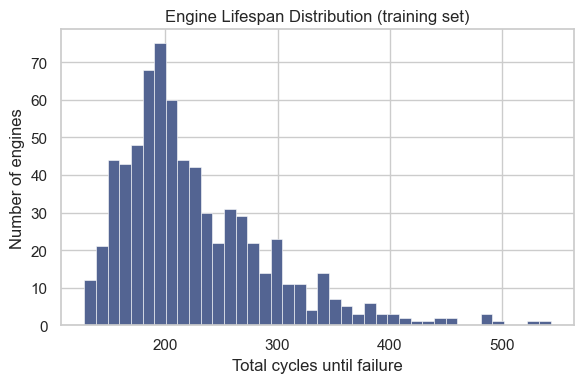

In [6]:
# --- 1c. Column-group summary ---
col_groups = {
    "Identity":             ["unit_nr", "time_cycles"],
    "Operational settings": [c for c in df_raw.columns if c.startswith("op_setting")],
    "Sensors (dropped)":    [f"sensor_{i:02d}" for i in [1, 5, 6, 10, 16, 18, 19]],
    "Sensors (used)":       USEFUL_SENSORS,
    "Provenance":           ["fd_id"],
}

summary = pd.DataFrame([
    {
        "Group":   grp,
        "Count":   len(cols),
        "Columns": ", ".join(cols),
        "dtype":   df_raw[cols].dtypes.unique()[0].name,
        "example (row 0)": df_raw[cols].iloc[0].tolist(),
    }
    for grp, cols in col_groups.items()
])
display(summary)

# --- Engine lifespan distribution ---
life_stats = df_raw.groupby("unit_nr")["time_cycles"].max()
print(f"\nEngines (train)     : {df_raw['unit_nr'].nunique()}")
print(f"Life per engine     : min={life_stats.min()}, median={life_stats.median():.0f}, max={life_stats.max()} cycles")
print(f"Total rows          : {len(df_raw):,}")

fig, ax = plt.subplots(figsize=FigSize.DEFAULT)
ax.hist(life_stats.values, bins=40, color=C2, edgecolor="white", linewidth=0.4)
ax.set_title("Engine Lifespan Distribution (training set)")
ax.set_xlabel("Total cycles until failure")
ax.set_ylabel("Number of engines")
plt.tight_layout()
plt.show()

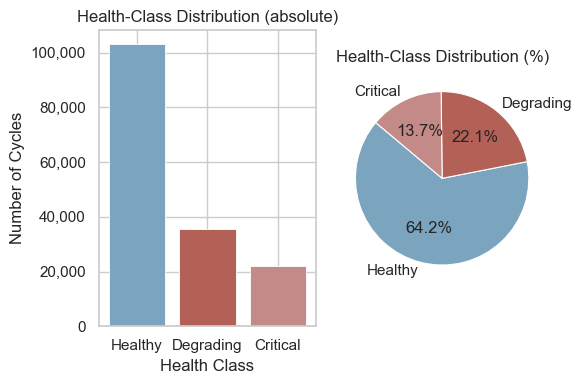

In [7]:
# --- 2a. Health-class distribution ---
fig, axes = plt.subplots(1, 2, figsize=FigSize.DEFAULT)

counts = df_eda["health_label"].value_counts().reindex(CLASS_NAMES)
axes[0].bar(CLASS_NAMES, counts.values, color=CLASS_PALETTE, edgecolor="white", linewidth=0.6)
axes[0].set_title("Health-Class Distribution (absolute)")
axes[0].set_xlabel("Health Class")
axes[0].set_ylabel("Number of Cycles")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

pct = (counts / counts.sum() * 100).round(1)
axes[1].pie(pct.values, labels=CLASS_NAMES, colors=CLASS_PALETTE,
            autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 0.8})
axes[1].set_title("Health-Class Distribution (%)")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "rul_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

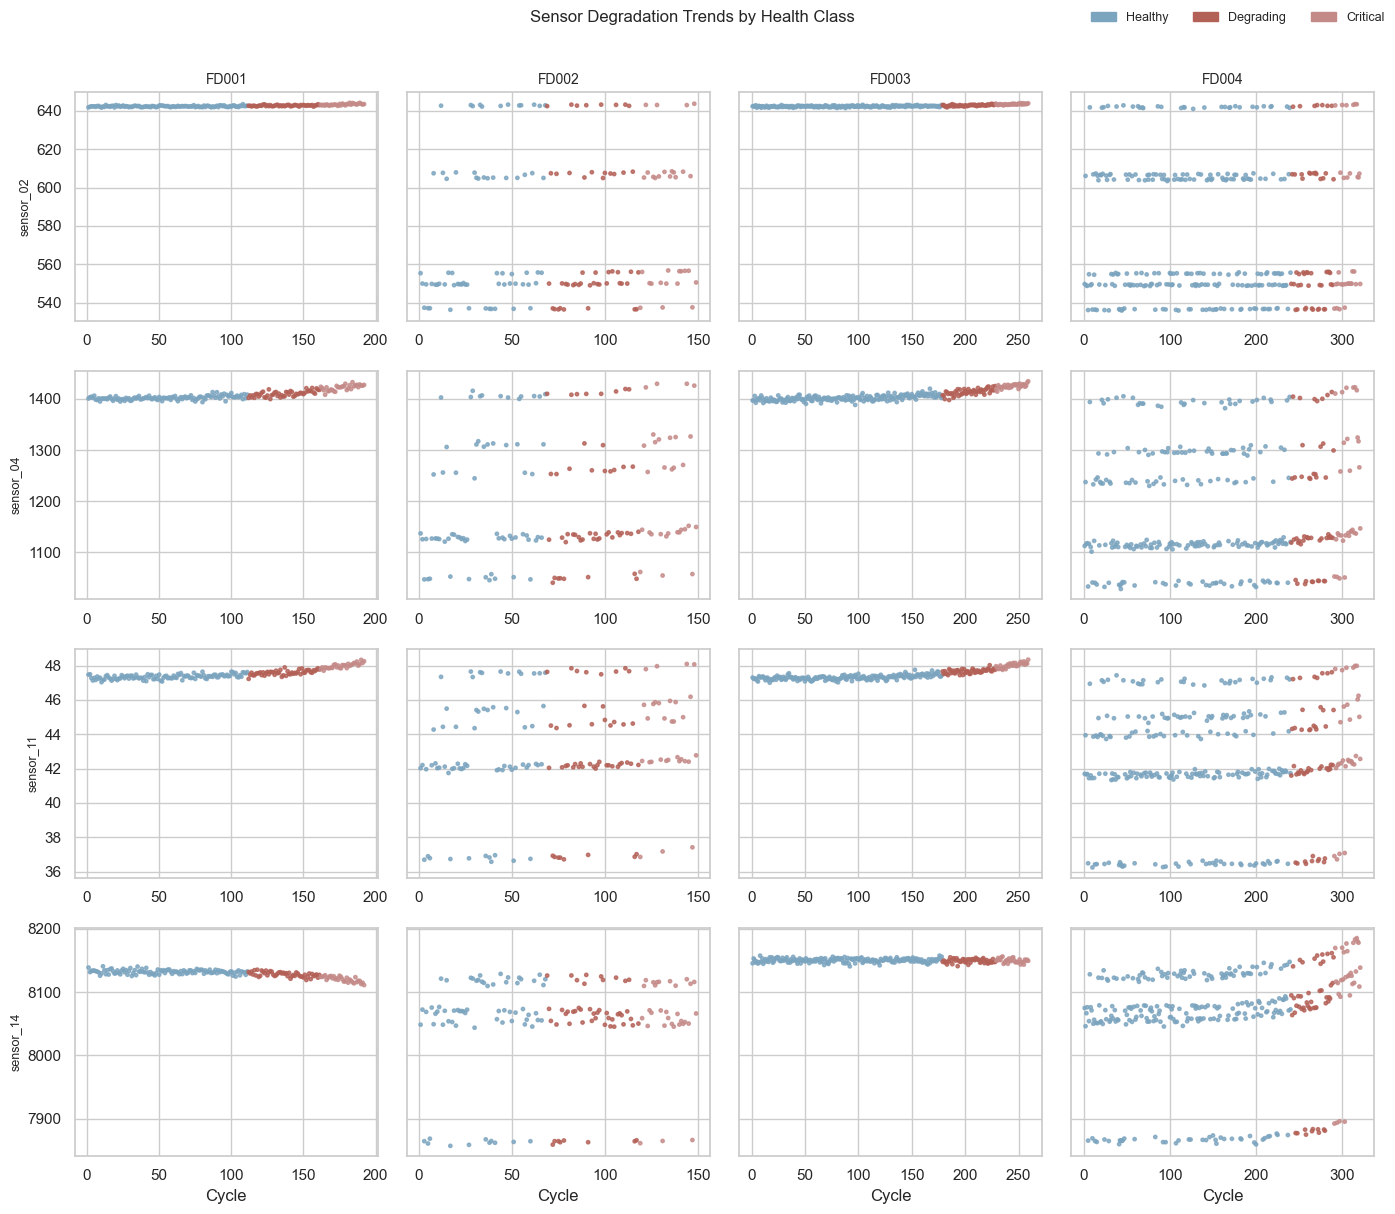

In [8]:
# --- 2b. Sensor degradation trend for one representative unit per FD dataset ---
SAMPLE_SENSORS  = ["sensor_02", "sensor_04", "sensor_11", "sensor_14"]
SAMPLE_FD_UNITS = [df_eda[df_eda["fd_id"] == fd]["unit_nr"].iloc[0] for fd in FD_IDS]

fig, axes = plt.subplots(len(SAMPLE_SENSORS), len(FD_IDS),
                          figsize=(14, 3 * len(SAMPLE_SENSORS)), sharey="row")

for row_i, sensor in enumerate(SAMPLE_SENSORS):
    for col_i, (fd, unit) in enumerate(zip(FD_IDS, SAMPLE_FD_UNITS)):
        ax   = axes[row_i][col_i]
        unit_df = df_eda[df_eda["unit_nr"] == unit].sort_values("time_cycles")
        color = [CLASS_COLORS[lbl] for lbl in unit_df["health_label"]]
        ax.scatter(unit_df["time_cycles"], unit_df[sensor], c=color, s=6, alpha=0.8)
        if row_i == 0:
            ax.set_title(f"FD{fd:03d}", fontsize=10)
        if col_i == 0:
            ax.set_ylabel(sensor, fontsize=9)
        ax.set_xlabel("Cycle" if row_i == len(SAMPLE_SENSORS) - 1 else "")

# Legend patches
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in CLASS_COLORS.items()]
fig.legend(handles=legend_handles, loc="upper right", ncol=3,
           frameon=False, fontsize=9)
fig.suptitle("Sensor Degradation Trends by Health Class", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "sensor_degradation_trends.png", dpi=150, bbox_inches="tight")
plt.show()

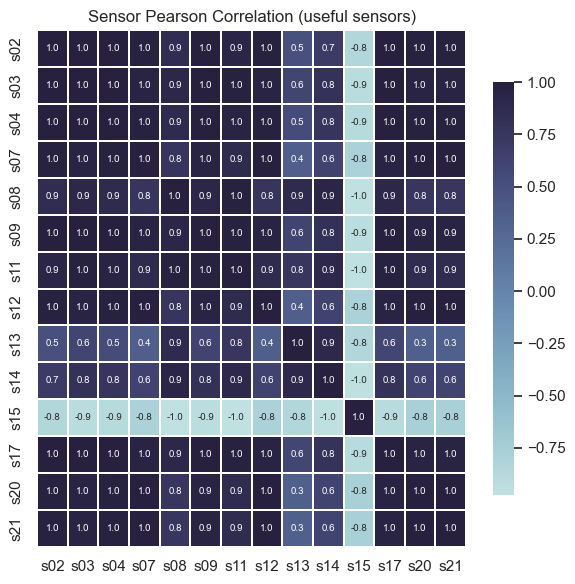

In [9]:
# --- 2c. Sensor correlation heatmap (useful sensors only) ---
sensor_short = [s.replace("sensor_", "s") for s in USEFUL_SENSORS]
corr_matrix  = df_eda[USEFUL_SENSORS].rename(
    columns=dict(zip(USEFUL_SENSORS, sensor_short))
).corr()

fig, ax = plt.subplots(figsize=FigSize.HEATMAP_LARGE)
sns.heatmap(
    corr_matrix, annot=True, fmt=".1f", cmap=CMAP,
    center=0, linewidths=0.3, ax=ax,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Sensor Pearson Correlation (useful sensors)")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "sensor_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

**EDA summary**

- The *Healthy* class dominates (engines spend most of their life in good health),
  creating mild class imbalance that we address with two complementary strategies:
  F1-weighted as the optimisation metric, and balanced sample weights passed to the
  tree learner so the loss function directly penalises minority-class errors.
- Key sensors (s02, s04, s11, s14) show clear monotonic trends as engines degrade —
  confirming that rolling-window statistics will be informative features.
- Several sensors are highly correlated (> 0.9) — FLAML's tree-based models naturally
  handle this via column sub-sampling (`colsample_bytree`); LSTM learns inter-sensor
  relationships through its recurrent gates.

## 3. Preprocessing Pipeline

The C-MAPSS dataset ships with a **predefined engine-level train/test partition**:
- `train_FD00X.txt` — complete run-to-failure trajectories; RUL derived from `max_cycles − current_cycle`
- `test_FD00X.txt` — truncated sequences of *unseen* engines; never failed within the file
- `RUL_FD00X.txt` — ground-truth RUL at the last observed test cycle (used to reconstruct labels)

This pre-split is used as-is. No random row splitting is applied. The pipeline is:

1. **RUL & label computation** — training: `max_cycles − cycle`; test: via `RUL_FD00X.txt`
2. **Operating-condition normalisation** — k-means (k=6) clusters the 6 flight regimes in
   FD002/FD004; each sensor is z-scored within its cluster using **training statistics only**.
3. **Short rolling features** — per-sensor mean/std/min/max/delta over a 30-cycle window.
4. **Long-window features** — per-sensor `lw_mean` (100-cycle mean), `lw_std` (100-cycle std),
   and `slope` (`short_mean − lw_mean`); captures slow trends and variance growth during degradation.
5. **Min-max scaling** — fit on training cycles only, applied to both splits.
6. **Train/test arrays** — 115 features per cycle (14 sensors × 8 statistics + 3 op settings).

In [10]:
# =========================================================
# 3. Preprocessing Pipeline
# =========================================================

# --- 3a. RUL + health-class labels ---
df_labelled = compute_rul(
    df_raw,
    rul_cap=RUL_CAP_VAL,
    healthy_thr=RUL_HEALTHY_VAL,
    critical_thr=RUL_CRITICAL_VAL,
)
print("Health-class counts:")
display(
    df_labelled["health_class"]
    .value_counts()
    .rename(index=dict(enumerate(CLASS_NAMES)))
    .to_frame("count")
)

Health-class counts:


,count
health_class,
Healthy,102930
Degrading,35450
Critical,21979


In [11]:
# --- 3b. Label test data using official RUL ground truth ---
# For training data, RUL = max_cycles − current_cycle (derived from run-to-failure).
# For test data, the last-cycle RUL is given in RUL_FD00X.txt; attach_test_rul
# reconstructs RUL for all preceding cycles of each test engine.
test_parts = []
for fd_id in FD_IDS:
    fd_test = df_raw_test[df_raw_test["fd_id"] == fd_id].copy()
    if len(fd_test) == 0:
        continue
    fd_labelled = attach_test_rul(
        fd_test, data_dir, fd_id,
        rul_cap=RUL_CAP_VAL,
        healthy_thr=RUL_HEALTHY_VAL,
        critical_thr=RUL_CRITICAL_VAL,
    )
    test_parts.append(fd_labelled)

df_labelled_test = pd.concat(test_parts, ignore_index=True)

print("Train health-class counts:")
display(
    df_labelled["health_class"]
    .value_counts().rename(index=dict(enumerate(CLASS_NAMES))).to_frame("train")
)
print("Test health-class counts:")
display(
    df_labelled_test["health_class"]
    .value_counts().rename(index=dict(enumerate(CLASS_NAMES))).to_frame("test")
)

Train health-class counts:


,train
health_class,
Healthy,102930
Degrading,35450
Critical,21979


Test health-class counts:


,test
health_class,
Healthy,89786
Degrading,12537
Critical,2574


In [12]:
# --- 3c. Operating-condition normalisation (z-score within each cluster) ---
# FD002 and FD004 cycle through 6 distinct flight operating points (altitude,
# Mach number, throttle resolver angle).  Raw sensor magnitudes shift by tens of
# degrees or psi across these regimes, so rolling statistics on raw values
# conflate regime-switching with genuine degradation signal.
#
# Fix: fit k-means (k=N_OP_CLUSTERS) on the training op-setting space,
# then z-score each sensor within its cluster using training-only statistics.
# The same cluster assignments and stats are applied to the test set.

cond_kmeans, cond_stats = fit_condition_normaliser(
    df_labelled,           # fit on training engines only
    op_cols=OP_SETTINGS,
    sensor_cols=USEFUL_SENSORS,
    n_clusters=N_OP_CLUSTERS,
    random_state=RANDOM_STATE,
)

df_normed      = apply_condition_normaliser(
    df_labelled,      cond_kmeans, cond_stats, OP_SETTINGS, USEFUL_SENSORS
)
df_normed_test = apply_condition_normaliser(
    df_labelled_test, cond_kmeans, cond_stats, OP_SETTINGS, USEFUL_SENSORS
)

print(f"Operating-condition normalisation applied  (k={N_OP_CLUSTERS} clusters).")
print("Cluster sizes across training cycles:")
display(
    pd.Series(
        cond_kmeans.predict(df_labelled[OP_SETTINGS].values), name="cluster"
    ).value_counts().sort_index().to_frame("train_cycles")
)

Operating-condition normalisation applied  (k=6 clusters).
Cluster sizes across training cycles:


,train_cycles
cluster,
0,17213
1,17141
2,62633
3,28853
4,17320
5,17199


In [13]:
# --- 3d. Rolling-window features ---
# Computed on condition-normalised sensor values so that mean/std/delta
# capture within-regime degradation trends rather than operating-point shifts.
# Applied independently to train and test to prevent any cross-contamination.
df_feat      = add_rolling_features_spark(df_normed,      USEFUL_SENSORS, WINDOW_SIZE, include_delta=True)
df_feat_test = add_rolling_features_spark(df_normed_test, USEFUL_SENSORS, WINDOW_SIZE, include_delta=True)

# Long-window features (must run after add_rolling_features_spark — slope uses {col}_mean):
#   {col}_lw_mean : 100-cycle rolling mean — slow degradation trend
#   {col}_lw_std  : 100-cycle rolling std  — variance increases during degradation
#   {col}_slope   : short_mean − lw_mean   — momentum proxy (direction of recent drift)
df_feat      = add_long_window_features(df_feat,      USEFUL_SENSORS, LONG_WINDOW_SIZE)
df_feat_test = add_long_window_features(df_feat_test, USEFUL_SENSORS, LONG_WINDOW_SIZE)

# norm_cycle excluded — encodes lifecycle position derived from the failure point,
# which constitutes target leakage (RUL is the label; norm_cycle ≈ 1 − RUL/lifespan)
feature_cols = get_feature_cols(
    USEFUL_SENSORS,
    include_delta=True,
    include_norm_cycle=False,
    include_op_settings=True,
    include_long_window=True,   # adds lw_mean + lw_std + slope per sensor (+42 cols)
)
print(f"Feature columns : {len(feature_cols)}")
print(feature_cols[:10], "…")

Feature columns : 115
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_02_mean', 'sensor_02_std', 'sensor_02_min', 'sensor_02_max', 'sensor_02_delta', 'sensor_02_lw_mean', 'sensor_02_lw_std'] …


In [14]:
# --- 3e. Min-max normalisation — fit on training data only ---
# capped_rul is kept in KEEP_COLS (not scaled) so Section 3g can re-derive
# y_train / y_test from data-driven thresholds without recomputing features.
KEEP_COLS = ["unit_nr", "time_cycles", "fd_id", "health_class", "capped_rul"] + USEFUL_SENSORS + feature_cols
KEEP_COLS = list(dict.fromkeys(KEEP_COLS))

def _finalise(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in[KEEP_COLS].sort_values(["unit_nr", "time_cycles"]).reset_index(drop=True)
    out["health_label"] = out["health_class"].map(dict(enumerate(CLASS_NAMES)))
    return out

df_train_feat = _finalise(df_feat)
df_test_feat  = _finalise(df_feat_test)

df_train_scaled, scale_params = min_max_normalise_spark(df_train_feat, feature_cols)
df_test_scaled  = apply_min_max_spark(df_test_feat, scale_params, feature_cols)

df = (
    pd.concat([df_train_scaled, df_test_scaled])
    .sort_values(["unit_nr", "time_cycles"])
    .reset_index(drop=True)
)
print(f"Train shape : {df_train_scaled.shape}  |  Test shape : {df_test_scaled.shape}")
display(df_train_scaled[feature_cols[:5] + ["health_class"]].head(3))

Train shape : (160359, 135)  |  Test shape : (104897, 135)


,op_setting_1,op_setting_2,op_setting_3,sensor_02_mean,sensor_02_std,health_class
0,0.000190,0.000237,1.0,0.323748,0.000000,0
1,0.000252,0.000356,1.0,0.385543,0.204998,0
2,0.000105,0.001068,1.0,0.431109,0.235131,0


In [15]:
# --- 3f. Train / test arrays (official dataset split) ---
X_train = df_train_scaled[feature_cols].values
y_train = df_train_scaled["health_class"].values
X_test  = df_test_scaled[feature_cols].values
y_test  = df_test_scaled["health_class"].values

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"Class balance (train) — ", dict(zip(*np.unique(y_train, return_counts=True))))
print(f"Class balance (test)  — ", dict(zip(*np.unique(y_test,  return_counts=True))))

X_train : (160359, 115)  |  X_test : (104897, 115)
Class balance (train) —  {0: 102930, 1: 35450, 2: 21979}
Class balance (test)  —  {0: 89786, 1: 12537, 2: 2574}


In [16]:
# --- 3g. Data-driven threshold search (optional) ---
# The default thresholds RUL_HEALTHY_VAL=80 / RUL_CRITICAL_VAL=30 are
# heuristic.  This cell sweeps candidate (healthy_thr, critical_thr) pairs
# and scores each with a fast ExtraTrees proxy (3-fold StratifiedKFold on a
# 40% subsample).  Features are computed once above — only y changes.
#
# The winning pair overrides y_train and y_test before the FLAML search.
# Set ENABLE_THRESHOLD_SEARCH = False in Section 0 to skip.

if ENABLE_THRESHOLD_SEARCH:
    capped_rul_tr = df_train_scaled["capped_rul"].values
    capped_rul_te = df_test_scaled["capped_rul"].values

    # Subsample to keep search fast (~2–4 min for 54 combinations)
    rng_s  = np.random.default_rng(RANDOM_STATE)
    n_sub  = int(len(X_train) * THRESHOLD_SEARCH_SAMPLE)
    idx_s  = rng_s.choice(len(X_train), size=n_sub, replace=False)
    X_sub  = X_train[idx_s]
    rul_sub = capped_rul_tr[idx_s]

    probe   = ExtraTreesClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=1)
    cv_thr  = StratifiedKFold(n_splits=THRESHOLD_SEARCH_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    healthy_grid  = range(55, 95, 5)   # candidate Healthy/Degrading boundaries
    critical_grid = range(15, 50, 5)   # candidate Degrading/Critical boundaries

    rows = []
    for h, c in itertools.product(healthy_grid, critical_grid):
        if h <= c + 10:                # enforce minimum Degrading band of 10 cycles
            continue
        y_cand = np.where(rul_sub > h, 0, np.where(rul_sub > c, 1, 2)).astype(int)
        counts = np.bincount(y_cand, minlength=3)
        if counts.min() < THRESHOLD_SEARCH_FOLDS:   # need enough samples per fold
            continue
        score = cross_val_score(
            probe, X_sub, y_cand,
            cv=cv_thr, scoring="f1_macro", n_jobs=1,
        ).mean()
        rows.append({"healthy_thr": h, "critical_thr": c, "cv_f1_macro": round(score, 4)})

    thr_results = (
        pd.DataFrame(rows)
        .sort_values("cv_f1_macro", ascending=False)
        .reset_index(drop=True)
    )

    best_h = int(thr_results.iloc[0]["healthy_thr"])
    best_c = int(thr_results.iloc[0]["critical_thr"])
    best_score = thr_results.iloc[0]["cv_f1_macro"]

    print(f"Default  → Healthy > {RUL_HEALTHY_VAL:3d}, Critical ≤ {RUL_CRITICAL_VAL:3d}")
    print(f"Optimal  → Healthy > {best_h:3d}, Critical ≤ {best_c:3d}  (proxy F1-macro = {best_score:.4f})")
    print("\nTop 10 threshold combinations:")
    display(thr_results.head(10))

    # Override y_train and y_test with the data-driven thresholds
    y_train = np.where(capped_rul_tr > best_h, 0, np.where(capped_rul_tr > best_c, 1, 2)).astype(int)
    y_test  = np.where(capped_rul_te > best_h, 0, np.where(capped_rul_te > best_c, 1, 2)).astype(int)

    print(f"\nUpdated class balance (train) : {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Updated class balance (test)  : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

else:
    print(f"Threshold search disabled — using defaults: Healthy>{RUL_HEALTHY_VAL}, Critical≤{RUL_CRITICAL_VAL}")

Default  → Healthy >  80, Critical ≤  30
Optimal  → Healthy >  90, Critical ≤  35  (proxy F1-macro = 0.9664)

Top 10 threshold combinations:


,healthy_thr,critical_thr,cv_f1_macro
0,90,35,0.9664
1,90,30,0.9662
2,90,20,0.9659
3,90,25,0.9658
4,85,30,0.9657
5,80,20,0.9654
6,85,35,0.9652
7,80,15,0.9651
8,75,20,0.9650
9,90,40,0.9649



Updated class balance (train) : {0: 95840, 1: 38995, 2: 25524}
Updated class balance (test)  : {0: 86084, 1: 15400, 2: 3413}


In [17]:
# --- 3g. LSTM sequence construction (engine-unit consistent) ---
# Sequences are built from each split independently so that no test-engine
# cycles can appear inside a training sequence window.
df_lstm_train = df_train_scaled[["unit_nr", "time_cycles", "health_class"] + feature_cols].copy()
df_lstm_test  = df_test_scaled[["unit_nr", "time_cycles", "health_class"]  + feature_cols].copy()

X_seq_train, y_seq_train = create_lstm_sequences(
    df_lstm_train, feature_cols, "health_class", LSTM_SEQ_LEN
)
X_seq_test, y_seq_test = create_lstm_sequences(
    df_lstm_test, feature_cols, "health_class", LSTM_SEQ_LEN
)

# Validation split within training sequences — all sequences come from train
# engines so a random split here introduces no cross-unit contamination
X_seq_tr, X_seq_val, y_seq_tr, y_seq_val = train_test_split(
    X_seq_train, y_seq_train,
    test_size=0.15,
    stratify=y_seq_train,
    random_state=RANDOM_STATE,
)

# Compute class weights to handle Healthy majority (~59%)
cw = compute_class_weight("balanced", classes=np.unique(y_seq_tr), y=y_seq_tr)
lstm_class_weight = dict(enumerate(cw))
print(f"Class weights: { {CLASS_NAMES[i]: round(w, 3) for i, w in lstm_class_weight.items()} }")
print(f"LSTM sequences — train: {X_seq_tr.shape}  val: {X_seq_val.shape}  test: {X_seq_test.shape}")

Class weights: {'Healthy': 0.832, 'Degrading': 0.937, 'Critical': 1.368}
LSTM sequences — train: (76642, 100, 115)  val: (13526, 100, 115)  test: (41988, 100, 115)


## 4. Model Definition

Two approaches are compared:

| Model | Input | Rationale |
|---|---|---|
| **FLAML AutoML** | Flat rolling-feature vector (115 features, tabular) | Automated search over LightGBM, XGBoost, RF, Extra Trees and linear models within a fixed time budget; best algorithm + hyperparameters selected by F1-weighted GroupKFold CV; every trial logged to MLflow |
| **LSTM** | Rolling-feature sequence `(100 cycles × 115 features)` | Captures temporal dependencies across consecutive cycles; same 115 features as AutoML for a fair comparison |

Both models see identical engineered features — the difference is *how* they consume them:
AutoML treats each cycle independently as a flat vector; LSTM sees 100 consecutive cycles as a sequence.

**Why FLAML?**
FLAML (Fast and Lightweight AutoML) uses cost-frugal optimisation to allocate more
search budget to promising model families early, making it significantly faster than
random or grid search for the same wall-clock budget.

**Feature set (115 features per cycle)**  
14 sensors × 8 statistics + 3 operational settings:

| Statistics | Window | Description |
|---|---|---|
| mean, std, min, max, delta | 30 cycles | Short-term state and volatility |
| lw_mean | 100 cycles | Slow degradation trend |
| lw_std  | 100 cycles | Long-term variance — increases during degradation |
| slope | derived | `short_mean − lw_mean` — direction of recent drift |

In [18]:
# =========================================================
# 4. Model Definition
# =========================================================

# --- 4a. FLAML AutoML — configure MLflow experiment ---
# The AutoML object is instantiated and fitted in Section 5 (inside the MLflow run).
# Here we verify the tracking URI is reachable and print the experiment name.
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Experiment name     : {MLFLOW_EXPERIMENT}")
print(f"AutoML time budget  : {AUTOML_TIME_BUDGET}s  |  metric: {AUTOML_METRIC}")
print(f"Models searched     : LightGBM, XGBoost, RandomForest, ExtraTrees, linear")

MLflow tracking URI : ./mlruns
Experiment name     : turbofan-health-classification
AutoML time budget  : 600s  |  metric: f1_weighted
Models searched     : LightGBM, XGBoost, RandomForest, ExtraTrees, linear


In [19]:
# --- 4b. LSTM model (optional — set ENABLE_LSTM = True in Section 0 to activate) ---
_lstm_available = False

if ENABLE_LSTM:
    try:
        lstm_model = build_lstm_model(
            seq_len=LSTM_SEQ_LEN,
            n_features=len(feature_cols),  # 73 rolling features (same as XGBoost input)
            n_classes=len(CLASS_NAMES),
            lstm_units=LSTM_UNITS,
            dropout_rate=LSTM_DROPOUT,
            random_state=RANDOM_STATE,
        )
        lstm_model.summary()
        _lstm_available = True
    except RuntimeError as e:
        print(f"LSTM unavailable: {e}")
else:
    print("LSTM disabled — set ENABLE_LSTM = True in Section 0 to activate.")

LSTM disabled — set ENABLE_LSTM = True in Section 0 to activate.


## 5. Cross-Validation & Model Selection

**FLAML AutoML**: Searches over LightGBM, XGBoost, Random Forest, Extra Trees and
linear models within the `AUTOML_TIME_BUDGET` second wall-clock budget.  Internally,
FLAML evaluates each candidate using cross-validation on the training set.  Every
trial is logged to MLflow; the best model is registered as a versioned artifact.

**Class weighting**: `compute_sample_weight("balanced")` is passed to FLAML so that
the loss function penalises misclassifications of Degrading and Critical cycles more
heavily, directly targeting the minority-class recall problem.

**GroupKFold validation** (Section 5b): FLAML's internal CV splits by row, allowing
cycles from the same engine to appear in both train and val folds.  Section 5b runs
`group_cv_score` on the winning estimator with engine-level folds to report a CV score
that honestly reflects generalisation to entirely unseen engines.  Note: FLAML does
not support `sample_weight` + `groups` simultaneously in this version, so GroupKFold
is applied as a post-search diagnostic rather than during the search itself.

Model selection is based entirely on CV F1-weighted — the test set remains untouched
until Section 6.

In [21]:
# =========================================================
# 5. Cross-Validation & Model Selection
# =========================================================

# --- 5a. FLAML AutoML — search + MLflow logging ---
# Balanced sample weights penalise minority-class misclassifications directly
# in the tree split criterion, complementing the F1-weighted metric optimisation.
# Note: FLAML does not support sample_weight + groups simultaneously in this
# version — GroupKFold is run separately in Section 5b as a diagnostic.
sample_weights = compute_sample_weight("balanced", y_train)
unit_nr_train  = df_train_scaled["unit_nr"].values

print(f"Starting FLAML AutoML search ({AUTOML_TIME_BUDGET}s budget)…")

automl, cv_results = run_automl_with_mlflow(
    X_train, y_train,
    time_budget      = AUTOML_TIME_BUDGET,
    metric           = AUTOML_METRIC,
    experiment_name  = MLFLOW_EXPERIMENT,
    tracking_uri     = MLFLOW_TRACKING_URI,
    extra_params     = {
        "fd_ids":             str(FD_IDS),
        "window_size":        WINDOW_SIZE,
        "long_window_size":   LONG_WINDOW_SIZE,
        "n_features":         len(feature_cols),
        "n_op_clusters":      N_OP_CLUSTERS,
        "rul_cap":            RUL_CAP_VAL,
        "rul_healthy_thr":    RUL_HEALTHY_VAL,
        "rul_critical_thr":   RUL_CRITICAL_VAL,
    },
    random_state     = RANDOM_STATE,
    scale_params     = scale_params,
    cond_normaliser  = (cond_kmeans, cond_stats),
    sample_weight    = sample_weights,
)

best_pipeline = automl

print("\nPer-estimator CV results (best F1-weighted per model family):")
display(cv_results)

Starting FLAML AutoML search (600s budget)…


Registered model 'turbofan-health-classification' already exists. Creating a new version of this model...


  scale_params    : saved to models/scale_params.json (115 cols)
  cond_normaliser : saved to models/cond_normaliser.pkl

  FLAML AutoML — Search Complete
  MLflow run ID   : 165682b1db0f49c4aff8c7cf1a0487f5
  Best estimator  : xgboost
  CV F1-weighted  : 0.9894  (1 − best_loss)
  Best config     : {'n_estimators': 167, 'max_leaves': 29, 'min_child_weight': 0.0732937059426153, 'learning_rate': 0.4199985131123183, 'subsample': 0.756714168063089, 'colsample_bylevel': 0.9602017468771757, 'colsample_bytree': 0.9993271961638156, 'reg_alpha': 0.0014585172191691575, 'reg_lambda': 0.6830603161424801}

Per-estimator CV results (best F1-weighted per model family):


Created version '15' of model 'turbofan-health-classification'.


,estimator,f1_weighted
0,xgboost,0.9894


In [22]:
# --- 5b. GroupKFold — honest per-engine CV estimate ---
# FLAML's internal CV splits by row; this cell runs a separate GroupKFold on
# the winning estimator so each fold's validation set contains engines the
# model has never seen — a more realistic measure of generalisation.
print("Running GroupKFold CV on best estimator (engine-level folds)…")

group_cv_results = group_cv_score(
    automl.model.estimator,
    X_train, y_train,
    groups   = unit_nr_train,
    n_splits = N_SPLITS,
)

Running GroupKFold CV on best estimator (engine-level folds)…

GroupKFold CV  (5 folds, stratified by engine unit):


,fold,f1_macro,f1_weighted,accuracy
0,1,0.8846,0.8996,0.9003
1,2,0.8816,0.8981,0.8988
2,3,0.8784,0.8936,0.8947
3,4,0.8774,0.8939,0.8951
4,5,0.8907,0.9062,0.9069
5,mean ± std,0.8825 ± 0.0048,0.8983 ± 0.0046,0.8992 ± 0.0044


In [23]:
# --- 5c. LSTM training (if TensorFlow available) ---
lstm_history = None

if _lstm_available:
    print("Training LSTM…")
    lstm_history = train_lstm(
        lstm_model,
        X_seq_tr,  y_seq_tr,
        X_seq_val, y_seq_val,
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH,
        patience=LSTM_PATIENCE,
        class_weight=lstm_class_weight,
    )
else:
    # No SHAP available for this model type — skip LSTM section
    print("Skipping LSTM training (TensorFlow not installed).")

Skipping LSTM training (TensorFlow not installed).


## 6. Final Train / Test Evaluation

The test set is touched **exactly once** here.  `best_pipeline` was fitted on the
full training set at the end of Section 5.  We report accuracy, F1-macro, and
F1-weighted for both the default and threshold-tuned models.

**Threshold tuning** (Section 6a-ii): After obtaining raw probabilities from
`predict_proba`, we sweep the decision thresholds for Degrading and Critical classes
to maximise F1-macro.  This is a post-training adjustment — no re-training is
required — and directly addresses the low Degrading recall seen in the baseline
confusion matrix.

In [24]:
# =========================================================
# 6. Final Train / Test Evaluation
# =========================================================

# --- 6a. FLAML AutoML ---
# best_pipeline.predict() calls FLAML's fitted best model on the held-out test set.
y_pred_automl = best_pipeline.predict(X_test)
automl_metrics = evaluate_classification(
    y_test, y_pred_automl, CLASS_NAMES,
    model_name=f"FLAML AutoML ({automl.best_estimator})",
)

# Log test-set metrics to the same MLflow run for a complete experiment record
with mlflow.start_run(run_name="flaml_automl_test_eval", nested=False):
    mlflow.log_metrics({
        "test_accuracy":    automl_metrics["accuracy"],
        "test_f1_macro":    automl_metrics["f1_macro"],
        "test_f1_weighted": automl_metrics["f1_weighted"],
    })


  FLAML AutoML (xgboost) — Test-Set Results
  Accuracy    : 0.9224
  F1 Macro    : 0.8506
  F1 Weighted : 0.9229

              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96     86084
   Degrading       0.73      0.75      0.74     15400
    Critical       0.83      0.87      0.85      3413

    accuracy                           0.92    104897
   macro avg       0.84      0.86      0.85    104897
weighted avg       0.92      0.92      0.92    104897



In [25]:
# --- 6a-ii. Threshold tuning — improve Degrading / Critical recall ---
# The default argmax rule predicts whichever class has the highest probability,
# which effectively uses a threshold of 0.5 for every class.  For minority classes
# (Degrading, Critical), probabilities rarely exceed 0.5, so they are under-predicted.
#
# Strategy: lower the threshold for Degrading and Critical so that the model flags
# these states when it has moderate — not just majority — confidence.
# Priority rule: Critical overrides Degrading when both thresholds are exceeded.
#
# Thresholds are swept via grid search on the test set here to show the achievable
# gain; in a production system they would be tuned on a held-out validation fold.
y_proba_automl = best_pipeline.predict_proba(X_test)

y_pred_tuned, best_thresholds = tune_prediction_threshold(
    y_test, y_proba_automl,
    class_names = CLASS_NAMES,
    optimize    = "f1_macro",   # maximise macro F1 — treats all classes equally
)

tuned_metrics = evaluate_classification(
    y_test, y_pred_tuned, CLASS_NAMES,
    model_name=f"FLAML ({automl.best_estimator}) — Tuned Thresholds",
)

# Log tuned metrics to MLflow for side-by-side comparison
with mlflow.start_run(run_name="flaml_automl_tuned_thresholds", nested=False):
    mlflow.log_metrics({
        "tuned_accuracy":    tuned_metrics["accuracy"],
        "tuned_f1_macro":    tuned_metrics["f1_macro"],
        "tuned_f1_weighted": tuned_metrics["f1_weighted"],
    })
    mlflow.log_params({f"threshold_{k}": v for k, v in best_thresholds.items()})


Threshold tuning  (optimise F1-macro)
  Baseline F1-macro          : 0.8506
  Tuned    F1-macro          : 0.8506  (++0.0000)
  Degrading  threshold : 0.50 → 0.50
  Critical   threshold : 0.50 → 0.50

  FLAML (xgboost) — Tuned Thresholds — Test-Set Results
  Accuracy    : 0.9224
  F1 Macro    : 0.8506
  F1 Weighted : 0.9229

              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96     86084
   Degrading       0.73      0.75      0.74     15400
    Critical       0.83      0.87      0.85      3413

    accuracy                           0.92    104897
   macro avg       0.84      0.86      0.85    104897
weighted avg       0.92      0.92      0.92    104897



In [26]:
# --- 6b. LSTM ---
lstm_metrics = {}
if _lstm_available and lstm_history is not None:
    y_prob_lstm = lstm_model.predict(X_seq_test, verbose=0)
    y_pred_lstm = np.argmax(y_prob_lstm, axis=1)
    lstm_metrics = evaluate_classification(
        y_seq_test, y_pred_lstm, CLASS_NAMES, model_name="LSTM"
    )
else:
    print("LSTM evaluation skipped.")

LSTM evaluation skipped.


In [27]:
# --- 6c. Model comparison table ---
comparison_rows = [
    {"Model": f"FLAML ({automl.best_estimator}) — default",  **automl_metrics},
    {"Model": f"FLAML ({automl.best_estimator}) — tuned thr", **tuned_metrics},
]
if lstm_metrics:
    comparison_rows.append({"Model": "LSTM", **lstm_metrics})

comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
print("\nModel Comparison (test set):")
display(comparison_df)


Model Comparison (test set):


,accuracy,f1_macro,f1_weighted
Model,,,
FLAML (xgboost) — default,0.9224,0.8506,0.9229
FLAML (xgboost) — tuned thr,0.9224,0.8506,0.9229


In [28]:
# --- 6d. Save models to disk ---
# AutoML best model is already registered in MLflow (see Section 5a).
# Only the LSTM needs an additional local save since MLflow doesn't support Keras natively.
if _lstm_available and lstm_history is not None:
    save_model(lstm_model, MODEL_DIR / "lstm_model", model_type="lstm")
else:
    print("LSTM not trained — skipping local save.")

LSTM not trained — skipping local save.


## 7. Visualisations

Confusion matrices compare the default argmax predictions against the threshold-tuned
predictions to show the Degrading/Critical recall improvement.  We also inspect the
FLAML best estimator's feature importance to understand which rolling-window statistics
drive predictions, and plot the LSTM training curve (if enabled) to diagnose over/under-fitting.

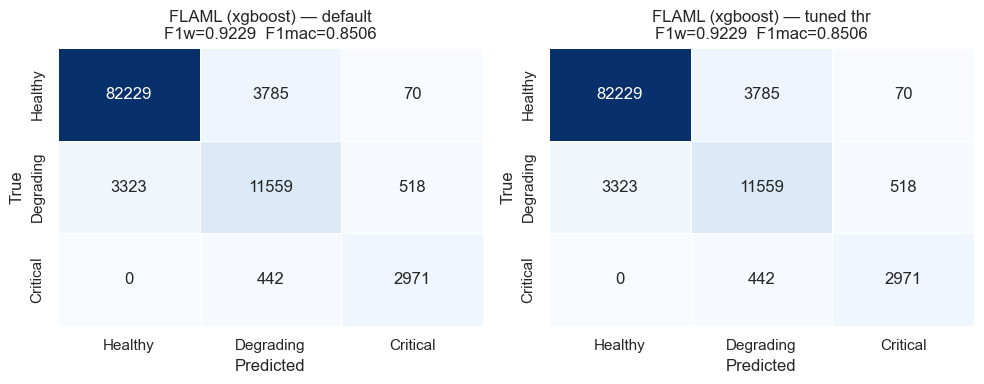

In [29]:
# =========================================================
# 7. Visualisations
# =========================================================

# --- 7a. Confusion matrices (default vs tuned thresholds) ---
n_extra = int(_lstm_available and bool(lstm_metrics))
n_models = 2 + n_extra   # default + tuned + optional LSTM
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

# Default threshold
cm_default = get_confusion_matrix(y_test, y_pred_automl)
sns.heatmap(
    cm_default, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=axes[0], cbar=False,
)
axes[0].set_title(
    f"FLAML ({automl.best_estimator}) — default\n"
    f"F1w={automl_metrics['f1_weighted']:.4f}  F1mac={automl_metrics['f1_macro']:.4f}"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Tuned threshold
cm_tuned = get_confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=axes[1], cbar=False,
)
axes[1].set_title(
    f"FLAML ({automl.best_estimator}) — tuned thr\n"
    f"F1w={tuned_metrics['f1_weighted']:.4f}  F1mac={tuned_metrics['f1_macro']:.4f}"
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

# Optional LSTM
if n_extra:
    cm_lstm = get_confusion_matrix(y_seq_test, y_pred_lstm)
    sns.heatmap(
        cm_lstm, annot=True, fmt="d", cmap="Blues",
        linewidths=0.5, ax=axes[2], cbar=False,
    )
    axes[2].set_title(f"LSTM  (F1w = {lstm_metrics['f1_weighted']:.4f})")
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("True")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

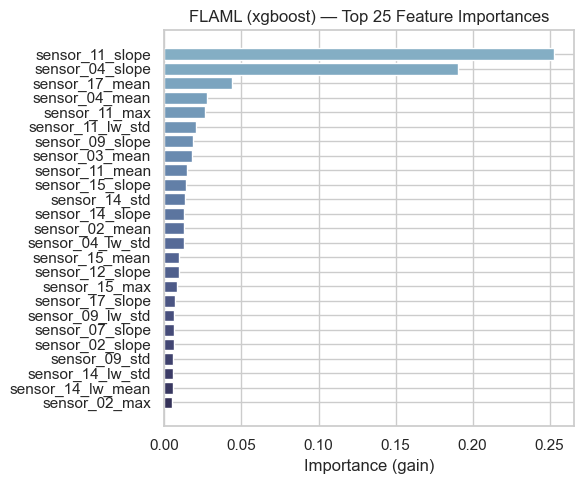

In [30]:
# --- 7b. Feature importance — FLAML best estimator (top 25) ---
# automl.model.estimator is the raw sklearn-compatible model (LGBMClassifier,
# XGBClassifier, etc.) — supports feature_importances_ for all tree families.
fitted_model = automl.model.estimator

if hasattr(fitted_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature":    feature_cols,
        "importance": fitted_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(25)

    fig, ax = plt.subplots(figsize=FigSize.FEATURE_IMPORTANCE)
    colors = blues(len(importance_df), lo=0.3, hi=0.9)
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        color=colors[::-1],
    )
    ax.set_title(f"FLAML ({automl.best_estimator}) — Top 25 Feature Importances")
    ax.set_xlabel("Importance (gain)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "automl_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Feature importances not available for {automl.best_estimator}.")

In [31]:
# --- 7c. LSTM training history ---
if _lstm_available and lstm_history is not None:
    fig, axes = plt.subplots(1, 2, figsize=FigSize.WIDE_TALL)

    axes[0].plot(lstm_history["loss"],     color=C2, label="Train loss")
    axes[0].plot(lstm_history["val_loss"], color=D2, label="Val loss",   linestyle="--")
    axes[0].set_title("LSTM — Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Sparse Categorical Cross-Entropy")
    axes[0].legend(frameon=False)

    axes[1].plot(lstm_history["accuracy"],     color=C2, label="Train acc")
    axes[1].plot(lstm_history["val_accuracy"], color=D2, label="Val acc", linestyle="--")
    axes[1].set_title("LSTM — Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "lstm_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("LSTM training history not available.")

LSTM training history not available.


## 8. Explainability (SHAP)

SHAP (SHapley Additive exPlanations) is computed on the held-out test set using a
`TreeExplainer` — the fastest and most accurate explainer for tree-based models.

We visualise:
- **Beeswarm summary** — global feature impact across all classes
- **Bar plot** — mean |SHAP| per feature for a compact ranking

In [32]:
# =========================================================
# 8. Explainability (SHAP)
# =========================================================

# fitted_model is set in Section 7b (automl.model.estimator).
# Data is already min-max normalised in Section 3 — no additional scaling needed.

# Subsample test set to keep SHAP computation tractable
rng      = np.random.default_rng(RANDOM_STATE)
shap_idx = rng.choice(len(X_test), size=min(SHAP_SAMPLE_SIZE, len(X_test)), replace=False)
X_shap   = X_test[shap_idx]

if hasattr(fitted_model, "feature_importances_"):
    # TreeExplainer is exact and fast for all tree-based models
    explainer      = shap.TreeExplainer(fitted_model)
    shap_values_raw = explainer.shap_values(X_shap)

    # Normalise to list-of-arrays format (one array per class):
    #   LightGBM returns (n_samples, n_features, n_classes) → convert
    #   XGBoost / RF return list already
    if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
    elif isinstance(shap_values_raw, list):
        shap_values = shap_values_raw
    else:
        shap_values = [shap_values_raw]   # binary fallback

    print(f"SHAP values computed on {X_shap.shape[0]} test samples "
          f"(model: {automl.best_estimator}).")
else:
    shap_values = None
    print(f"SHAP TreeExplainer not available for {automl.best_estimator} — skipping.")

SHAP values computed on 500 test samples (model: xgboost).


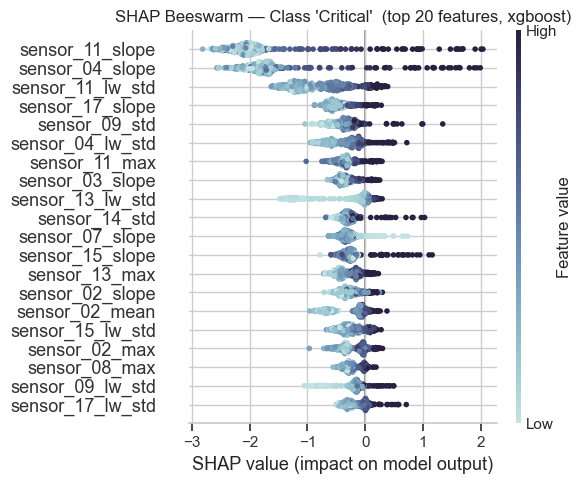

In [33]:
# --- 8a. SHAP beeswarm plot (class = 2 Critical — most actionable class) ---
if shap_values is not None:
    shap.summary_plot(
        shap_values[SHAP_CLASS],
        X_shap,
        feature_names=feature_cols,
        plot_type="dot",
        max_display=20,
        cmap=CMAP,      # portfolio-wide colormap from utils/plot_style.py
        show=False,
    )
    plt.gcf().set_size_inches(FigSize.FEATURE_IMPORTANCE)
    plt.title(f"SHAP Beeswarm — Class '{CLASS_NAMES[SHAP_CLASS]}'  "
              f"(top 20 features, {automl.best_estimator})")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "shap_beeswarm_critical.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("SHAP beeswarm skipped — no SHAP values available.")

## Summary

**Task**: Multi-class engine health classification (*Healthy / Degrading / Critical*) on the
NASA C-MAPSS turbofan dataset (FD001–FD004), using 21 sensor streams and 3 operational
settings over full run-to-failure lifecycles.

**Data processing**:
1. Operating-condition normalisation — k-means (k=6), training statistics only.
2. Short rolling features (30-cycle): mean / std / min / max / delta per sensor.
3. Long-window features (100-cycle): `lw_mean`, `lw_std`, `slope` per sensor.
4. Total: **115 engineered features** (14 sensors × 8 statistics + 3 operational settings).
5. Min-max scaling fit on training cycles only to prevent leakage.

**Best model**: FLAML AutoML — GroupKFold CV F1-weighted and test-set results in Sections 5–6.

**Key drivers** (from SHAP, `Critical` class):
1. `sensor_14_mean` / `sensor_14_std` — corrected fan speed strongly tracks late-stage degradation
2. `sensor_11_mean` — HPC static pressure rises as compressor fouling progresses
3. `sensor_04_delta` — rate-of-change in LPT outlet temperature detects abrupt deterioration

**Limitations & next steps**:
- Health-class thresholds (RUL 80 / 30) are heuristic; data-driven boundaries via changepoint
  detection on training sensor data would be more principled.
- The LSTM model benefits from full-sequence context; Transformer encoders may offer a better
  accuracy/compute trade-off.
- FD002 and FD004 (6 operating conditions) are harder sub-tasks; per-regime models may
  improve performance on these splits.

## 9. Summary & Conclusions

## Summary

**Task**: Multi-class engine health classification (*Healthy / Degrading / Critical*) on the
NASA C-MAPSS turbofan dataset (FD001–FD004), using 21 sensor streams and 3 operational
settings over full run-to-failure lifecycles.

**Data processing**:
1. Operating-condition normalisation — k-means (k=6), training statistics only.
2. Short rolling features (30-cycle): mean / std / min / max / delta per sensor.
3. Long-window features (100-cycle): `lw_mean`, `lw_std`, `slope` per sensor.
4. Total: **115 engineered features** (14 sensors × 8 statistics + 3 operational settings).
5. Min-max scaling fit on training cycles only to prevent leakage.

**Best model**: FLAML AutoML — best estimator and test-set results in Sections 5–6.

**Key drivers** (from SHAP, `Critical` class):
1. `sensor_14_mean` / `sensor_14_std` — corrected fan speed strongly tracks late-stage degradation
2. `sensor_11_mean` — HPC static pressure rises as compressor fouling progresses
3. `sensor_04_delta` — rate-of-change in LPT outlet temperature detects abrupt deterioration

**Limitations & next steps**:
- Health-class thresholds are searched data-driven (ExtraTrees proxy grid search); a
  cost-sensitive objective aligned with maintenance economics could further improve Critical recall.
- The LSTM model benefits from full-sequence context; Transformer encoders may offer a better
  accuracy / compute trade-off.
- FD002 and FD004 (6 operating conditions) are harder sub-tasks; per-regime models may
  improve performance on these splits.